In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

YOLO-Kaggle Results

In [4]:

# Daten aus der Benutzereingabe
data = [
    {
        "Fold": 1,
        "mAP50": 0.994592,
        "mAP50-95": 0.819206,
        "precision": [0.9772674114421703],
        "recall": [1.0]
    },
    {
        "Fold": 2,
        "mAP50": 0.994444,
        "mAP50-95": 0.831578,
        "precision": [0.9797221042867775],
        "recall": [1.0]
    },
    {
        "Fold": 3,
        "mAP50": 0.994600,
        "mAP50-95": 0.788892,
        "precision": [1.0],
        "recall": [0.9751540154585319]
    },
    {
        "Fold": 4,
        "mAP50": 0.985325,
        "mAP50-95": 0.808739,
        "precision": [0.9987336240133619],
        "recall": [0.9615384615384616]
    },
    {
        "Fold": 5,
        "mAP50": 0.995000,
        "mAP50-95": 0.851857,
        "precision": [0.9994167272567542],
        "recall": [1.0]
    }
]

df = pd.DataFrame(data)

# Werte aus den Listen extrahieren (da nur 1 Klasse/Wert vorhanden ist)
df['precision'] = df['precision'].apply(lambda x: x[0])
df['recall'] = df['recall'].apply(lambda x: x[0])

# Zusammenfassung berechnen
summary = df.drop(columns=['Fold']).agg(['mean', 'std'])

round(summary.T.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

,Mean,Std +-
mAP50,0.993,0.004
mAP50-95,0.820,0.024
precision,0.991,0.011
recall,0.987,0.018


RF-DETR-Kaggle Results

In [3]:
# 1. Daten in eine vergleichbare Struktur bringen
metrics = ["Precision",'Recall',"F1", 'mAP@50', 'mAP@[50:95]']
yolo_values = [yolo_kaggle_val["kaggle/precision"], yolo_kaggle_val['kaggle/recall'],yolo_kaggle_val["kaggle/f1"] ,yolo_kaggle_val['kaggle/mAP50'], yolo_kaggle_val['kaggle/mAP50-95']]
rfdetr_values = [rfdetr_kaggle_val["rf-detr/precision"], rfdetr_kaggle_val['rf-detr/recall'],rfdetr_kaggle_val["rf-detr/f1"] ,rfdetr_kaggle_val['rf-detr/mAP50'], rfdetr_kaggle_val['rf-detr/mAP50-95']]

# 2. DataFrame für Matplotlib erstellen
data = {
    'Metric': metrics * 2,
    'Model': ['YOLO'] * len(metrics) + ['RF-DETR'] * len(metrics),
    'Value': yolo_values + rfdetr_values
}
df = pd.DataFrame(data)

# Werte für die Gruppierung vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(metrics))

# Daten für die Modelle filtern
df_yolo = df[df['Model'] == 'YOLO']
df_rfdetr = df[df['Model'] == 'RF-DETR']

# Balken für YOLO plotten (links in der Gruppe)
bar1 = ax.bar(index, df_yolo['Value'], bar_width, label='YOLO', color='#36A2EB')

# Balken für RF-DETR plotten (rechts in der Gruppe)
bar2 = ax.bar(index + bar_width, df_rfdetr['Value'], bar_width, label='RF-DETR', color='#FF6384')

# 3. Diagramm formatieren
ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Metrics comparison (Dataset B)', fontsize=14)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05) # Y-Achse von 0 bis 1.05
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Werte auf die Balken schreiben
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 Punkte vertikaler Versatz
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

add_labels(bar1)
add_labels(bar2)

plt.tight_layout()
plt.show()

NameError: name 'yolo_kaggle_val' is not defined

Yolo-Roboflow Results

In [24]:
# Deine Ergebnisse aus der 5-Fold Cross-Validation
data = [
    {
        "fold": 1,
        "mAP50": 0.817217,
        "mAP50-95": 0.563044,
        "precision": [0.7514621966286971, 0.9671146226696267],
        "recall": [0.5702702702702702, 0.9166666666666666]
    },
    {
        "fold": 2,
        "mAP50": 0.837757,
        "mAP50-95": 0.589359,
        "precision": [0.7385323545021348, 0.9627684545208934],
        "recall": [0.6494995472899632, 0.9715799732608127]
    },
    {
        "fold": 3,
        "mAP50": 0.835691,
        "mAP50-95": 0.567396,
        "precision": [0.7381310342963431, 0.9619391630191857],
        "recall": [0.6630434782608695, 0.9468563665758085]
    },
    {
        "fold": 4,
        "mAP50": 0.825140,
        "mAP50-95": 0.579171,
        "precision": [0.7367265344526664, 0.9684008740259846],
        "recall": [0.6235435144157984, 0.9596541786743515]
    },
    {
        "fold": 5,
        "mAP50": 0.824331,
        "mAP50-95": 0.585665,
        "precision": [0.6915238029656346, 0.9463481568322523],
        "recall": [0.6657824933687002, 0.976878612716763]
    }
]

# DataFrame erstellen
df = pd.DataFrame(data)

# Precision & Recall Listen aufsplitten: Index 0 = Defect, Index 1 = Glass
df['precision_defect'] = df['precision'].apply(lambda x: x[0])
df['precision_glass'] = df['precision'].apply(lambda x: x[1])
df['recall_defect'] = df['recall'].apply(lambda x: x[0])
df['recall_glass'] = df['recall'].apply(lambda x: x[1])

# Alte Spalten entfernen und sortieren
df_final = df.drop(columns=['precision', 'recall'])
df_final = df_final[['fold', 'mAP50', 'mAP50-95', 
                     'precision_defect', 'precision_glass', 
                     'recall_defect', 'recall_glass']]

# Berechnung von Mittelwert (mean) und Standardabweichung (std)
summary = df_final.drop(columns=['fold']).agg(['mean', 'std'])

round(summary.T.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

,Mean,Std +-
mAP50,0.828,0.009
mAP50-95,0.577,0.011
precision_defect,0.731,0.023
precision_glass,0.961,0.009
recall_defect,0.634,0.040
recall_glass,0.954,0.024


RF-DETR-Roboflow Results

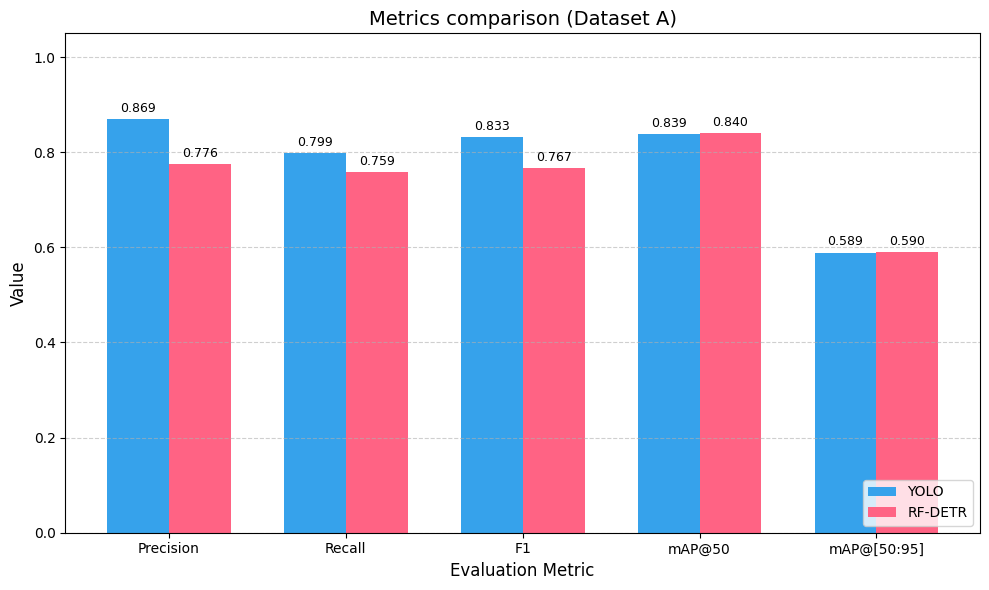

In [7]:
### Plot the results
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Daten in eine vergleichbare Struktur bringen
metrics = ["Precision",'Recall',"F1", 'mAP@50', 'mAP@[50:95]']
yolo_values = [yolo_roboflow["yolo/precision"], yolo_roboflow['yolo/recall'],yolo_roboflow["yolo/f1"], yolo_roboflow['yolo/mAP50'], yolo_roboflow['yolo/mAP50-95']]
rfdetr_values = [rfdetr_roboflow["rfdetr/precision"], rfdetr_roboflow['rfdetr/recall'],rfdetr_roboflow["rfdetr/F1"] ,rfdetr_roboflow['rfdetr/mAP50'], rfdetr_roboflow['rfdetr/mAP50-95']]

# 2. DataFrame für Matplotlib erstellen
data = {
    'Metric': metrics * 2,
    'Model': ['YOLO'] * len(metrics) + ['RF-DETR'] * len(metrics),
    'Value': yolo_values + rfdetr_values
}
df = pd.DataFrame(data)

# Werte für die Gruppierung vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(metrics))

# Daten für die Modelle filtern
df_yolo = df[df['Model'] == 'YOLO']
df_rfdetr = df[df['Model'] == 'RF-DETR']

# Balken für YOLO plotten (links in der Gruppe)
bar1 = ax.bar(index, df_yolo['Value'], bar_width, label='YOLO', color='#36A2EB')

# Balken für RF-DETR plotten (rechts in der Gruppe)
bar2 = ax.bar(index + bar_width, df_rfdetr['Value'], bar_width, label='RF-DETR', color='#FF6384')

# 3. Diagramm formatieren
ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Metrics comparison (Dataset A)', fontsize=14)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05) # Y-Achse von 0 bis 1.05
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Werte auf die Balken schreiben
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 Punkte vertikaler Versatz
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

add_labels(bar1)
add_labels(bar2)

plt.tight_layout()
plt.show()

Training RF-DETR- Dataset B

Yolo Kaggle

In [51]:
metric_names_yolo_b = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]

mean_yolo_b = [0.9944, 0.9928, 0.9918, 0.8105]
std_yolo_b = [0.0109, 0.0107, 0.0069, 0.0189]

df_yolo_b = pd.DataFrame({
    "Metric": metric_names_yolo_b,
    "Mean": mean_yolo_b,
    "Std. (+-)": std_yolo_b
}
)

df_yolo_b.style.hide(axis="index")
round(df_yolo_b, 3)

,Metric,Mean,Std. (+-)
0,Precision,0.994,0.011
1,Recall,0.993,0.011
2,mAP50,0.992,0.007
3,mAP50-95,0.810,0.019


Yolo Roboflow

In [4]:
metric_names_yolo_a = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]

mean_yolo_a = [0.8409, 0.7900, 0.8221, 0.5768]
std_yolo_a = [0.0173, 0.0161, 0.0149, 0.0066]

df_yolo_a = pd.DataFrame({
    "Metric": metric_names_yolo_a,
    "Mean": mean_yolo_a,
    "Std. (+-)": std_yolo_a
}
)

df_yolo_a

,Metric,Mean,Std. (+-)
0,Precision,0.841,0.017
1,Recall,0.790,0.016
2,mAP50,0.822,0.015
3,mAP50-95,0.577,0.007


RF-DETR-Roboflow Results

RF-DETR-Kaggle 5-Fold-CV-Val

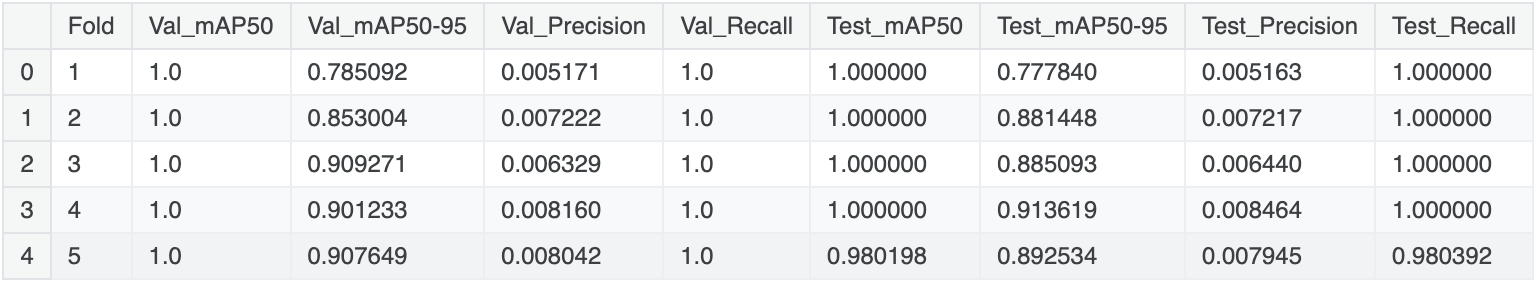


In [19]:
import pandas as pd

# Daten basierend auf dem Screenshot
data_val = {
    'Fold': [1, 2, 3, 4, 5],
    # Validation Daten
    'Val_mAP50': [1.0, 1.0, 1.0, 1.0, 1.0],
    'Val_mAP50-95': [0.785670, 0.853004, 0.909271, 0.901233, 0.907649],
    'Val_Precision': [1, 1, 1, 1, 1], ## from confusion, with Precision() its not quite right
    'Val_Recall': [1.0, 1.0, 1.0, 1.0, 1.0],
}


# Erstellen des gesamten DataFrames
df_val = pd.DataFrame(data_val)

# Aufteilen in 'Val' und 'Test' (da keine 'Train' Daten im Bild sind)
df_val = df_val[['Fold', 'Val_mAP50', 'Val_mAP50-95', 'Val_Precision', 'Val_Recall']].copy()

num_cols_val = [col for col in df_val if col != "Fold"]

# Ausgabe zur Überprüfung



# Zusammenfassung berechnen
summary_val = df_val.drop(columns=['Fold']).agg(['mean', 'std'])

summary_val.T.style.format("{:.3f}")

# round(summary_val.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

# summary_val.T.style.format("{:.3f}", subset=num_cols_val).hide(axis="index")


,mean,std
Val_mAP50,1.000,0.000
Val_mAP50-95,0.871,0.053
Val_Precision,1.000,0.000
Val_Recall,1.000,0.000


RF-DETR-Kaggle 5-Fold-CV-Test

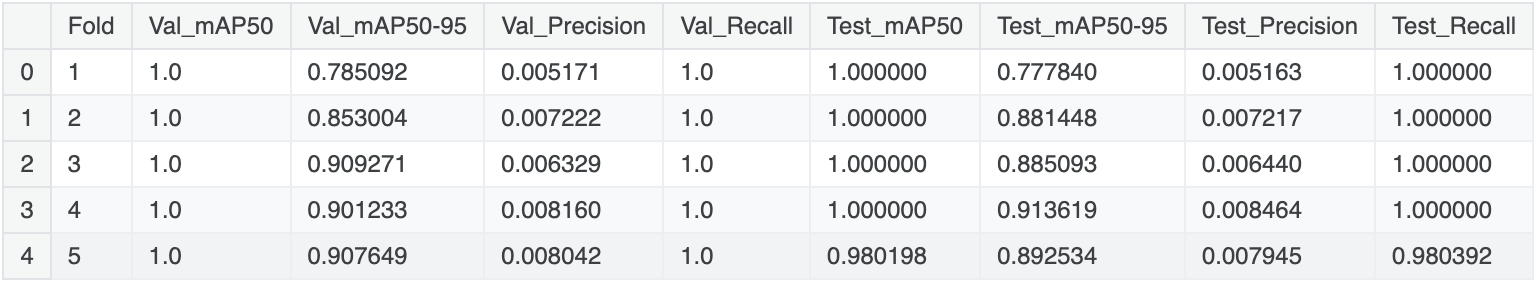

In [25]:
import pandas as pd


data_test = {
    'Fold': [1, 2, 3, 4, 5],
    'Test_mAP50': [1.000000, 1.000000, 1.000000, 1.000000, 0.980198],
    'Test_mAP50-95': [0.777840, 0.881448, 0.885093, 0.913619, 0.892534],
    'Test_Precision': [0.011035, 0.009760, 0.011751, 0.010036, 0.014676],
    'Test_Recall': [1.000000, 1.000000, 1.000000, 1.000000, 0.980392]
}

df_test = pd.DataFrame(data_test)

df_test = df_test[['Fold', 'Test_mAP50', 'Test_mAP50-95', 'Test_Precision', 'Test_Recall']].copy()


num_cols_test = [col for col in df_test if col != "Fold"]

# Zusammenfassung berechnen
summary_test = df_test.drop(columns=['Fold']).agg(['mean', 'std'])

summary_test.T.rename({"mean": "Mean", "std": "Std (+-)"}).style.format("{:.3f}")

# summary_test.T.style.format("{:.3f}")

,mean,std
Test_mAP50,0.996,0.009
Test_mAP50-95,0.870,0.053
Test_Precision,0.011,0.002
Test_Recall,0.996,0.009


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Construct the 2x2 Matrix Data ---
# Classes: 0=defect, 1=Background

# Row 0 (True: defect)

row_defect = [50, 1] 

# Row 1 (True: glass)

row_glass = [0, 0] 


cm_2x2_data = np.array([
    row_defect, 
    row_glass, 
])

labels_2x2 = ['DEFECT', 'no defect']


# --- 2. Plot the 2x2 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_2x2_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=labels_2x2,
    yticklabels=labels_2x2
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF-DETR, Kaggle Fold 5')
plt.show()

# Print the matrix for easy reference
print("\nConsolidated 2x2 Matrix (True Row vs. Predicted Column):\n")
df = pd.DataFrame(cm_2x2_data, index=labels_2x2, columns=labels_2x2)
print(df)

RF-DETR Kaggle Val Prec

In [9]:
import pandas as pd

TP=[31, 28, 28, 29, 32]
TN=[0, 0, 0, 0, 0]
FP=[0, 0, 0, 0, 0]
FN=[0, 0, 0, 0 , 0]

folds = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]

# A list to store the results for each fold
results_per_fold = []

# Unpack the tuple from zip into meaningful variable names
for fold_name, tp_val, tn_val, fp_val, fn_val in zip(folds, TP, TN, FP, FN):
    # Handle division by zero for precision
    if (tp_val + fp_val) == 0:
        precision_rfdetr = 0.0
    else:
        precision_rfdetr = tp_val / (tp_val + fp_val)

    # Handle division by zero for recall
    if (tp_val + fn_val) == 0:
        recall_rfdetr = 0.0
    else:
        recall_rfdetr = tp_val / (tp_val + fn_val)
    
    # Handle division by zero for F1 score
    if (precision_rfdetr + recall_rfdetr) == 0:
        f1_rfdetr = 0.0
    else:
        f1_rfdetr = 2 * (precision_rfdetr * recall_rfdetr) / (precision_rfdetr + recall_rfdetr)
    
    # Create a dictionary for the current fold's results
    fold_results = {
        "Fold": fold_name,
        "Precision": precision_rfdetr,
        # "Recall": recall_rfdetr,
        # "F1": f1_rfdetr,
        # "mAP50": map50_val,
        # "mAP50-95": map5095_val
    }
    
    # Add the dictionary to our list of results
    results_per_fold.append(fold_results)

numeric_cols = [col for col in fold_results.keys() if col != "Fold"]

# Create a DataFrame from the list of dictionaries for a nice display
df_results = pd.DataFrame(results_per_fold)
# Werte aus den Listen extrahieren (da nur 1 Klasse/Wert vorhanden ist)
# df_results['Precision'] = df_results['Precision'].apply(lambda x: x[0])
# df_results['recall'] = df_results['recall'].apply(lambda x: x[0])

# Zusammenfassung berechnen
summary_rfdetr_kaggle_prec_val = df_results.drop(columns=['Fold']).agg(['mean', 'std'])


round(summary_rfdetr_kaggle_prec_val.T.rename(columns={"mean": "Mean", "std": "Std +-"}),3)

# df_results.style.format('{:.3f}', subset=numeric_cols).hide(axis="index")


,Mean,Std +-
Precision,1.0,0.0


RF-DETR-Kaggle Prec Test

In [26]:
TP=[53, 48, 49, 47, 50]
TN=[0, 0, 0, 0, 0]
FP=[1, 0, 0, 0, 0]
FN=[0, 0, 0, 0 , 1]

folds = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]

# A list to store the results for each fold
results_per_fold = []

# Unpack the tuple from zip into meaningful variable names
for fold_name, tp_val, tn_val, fp_val, fn_val in zip(folds, TP, TN, FP, FN):
    # Handle division by zero for precision
    if (tp_val + fp_val) == 0:
        precision_rfdetr = 0.0
    else:
        precision_rfdetr = tp_val / (tp_val + fp_val)

    # Handle division by zero for recall
    if (tp_val + fn_val) == 0:
        recall_rfdetr = 0.0
    else:
        recall_rfdetr = tp_val / (tp_val + fn_val)
    
    # Handle division by zero for F1 score
    if (precision_rfdetr + recall_rfdetr) == 0:
        f1_rfdetr = 0.0
    else:
        f1_rfdetr = 2 * (precision_rfdetr * recall_rfdetr) / (precision_rfdetr + recall_rfdetr)
    
    # Create a dictionary for the current fold's results
    fold_results = {
        "Fold": fold_name,
        "Precision": precision_rfdetr,
        # "Recall": recall_rfdetr,
        # "F1": f1_rfdetr,
        # "mAP50": map50_val,
        # "mAP50-95": map5095_val
    }
    
    # Add the dictionary to our list of results
    results_per_fold.append(fold_results)

numeric_cols = [col for col in fold_results.keys() if col != "Fold"]

# Create a DataFrame from the list of dictionaries for a nice display
df_results = pd.DataFrame(results_per_fold)

df_results.style.format('{:.3f}', subset=numeric_cols).hide(axis="index")


Fold,Precision
Fold 1,0.981
Fold 2,1.000
Fold 3,1.000
Fold 4,1.000
Fold 5,1.000


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Construct the 3x3 Matrix Data ---
# Classes: 0=defect, 1=glass, 2=Background

# Row 0 (True: defect)
# P: defect (141), P: glass (1), P: Background (FN = 55)
row_defect = [141, 1, 55] 

# Row 1 (True: glass)
# P: defect (50), P: glass (173), P: Background (FN for glass, assumed 0)
row_glass = [0, 173, 0] 

# Row 2 (True: Background)
# P: defect (FP = 50), P: glass (FP for glass, assumed 0), P: Background (TN, assumed 0)
row_background = [50, 0, 0]

cm_3x3_data = np.array([
    row_defect, 
    row_glass, 
    row_background
])

labels_3x3 = ['defect', 'glass', 'no defect']


# --- 2. Plot the 3x3 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_3x3_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=labels_3x3,
    yticklabels=labels_3x3
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF-DETR, Roboflow')
plt.show()

# Print the matrix for easy reference
print("\nConsolidated 3x3 Matrix (True Row vs. Predicted Column):\n")
df = pd.DataFrame(cm_3x3_data, index=labels_3x3, columns=labels_3x3)
print(df)